# Step 2 — Exploratory Visualization

Before running a single statistical test, we look at the data. Plots catch bugs
and build intuition that summary numbers hide.

Four plots this step:
1. Raw prices and log prices side-by-side
2. Daily returns time series + distribution
3. Rolling 63-day correlation
4. Raw KO/PEP price ratio (preview of the spread before we fit β)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, str(Path.cwd().parent))

from pairs_trading.data import load_or_fetch

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

KO_COLOR  = "#F40009"   # Coke red
PEP_COLOR = "#004B93"   # Pepsi blue

def fmt_dates(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.figure.autofmt_xdate(rotation=0, ha="center")

In [2]:
prices = load_or_fetch(["KO", "PEP"], "2018-01-01", "2025-01-01", name="ko_pep_7yr")
returns = prices.pct_change().dropna()
print(f"{len(prices)} trading days loaded.")

Loading from cache: c:\Users\delosreyes.i\Downloads\Quant Claude Project\Pair-Regression-Testing\pairs_trading\data\ko_pep_7yr.parquet
1761 trading days loaded.


## Plot 1 — Prices and Log Prices

**Why log prices?** Pairs trading math is done in log-price space. If the log-price
spread `log(KO) - β·log(PEP)` is stationary, the pair is cointegrated.
Looking at log prices tells us whether the series move together *proportionally*
rather than just in absolute dollar terms.

What to look for: do both lines generally trend together? Any obvious divergences
or weird vertical jumps (data errors)?

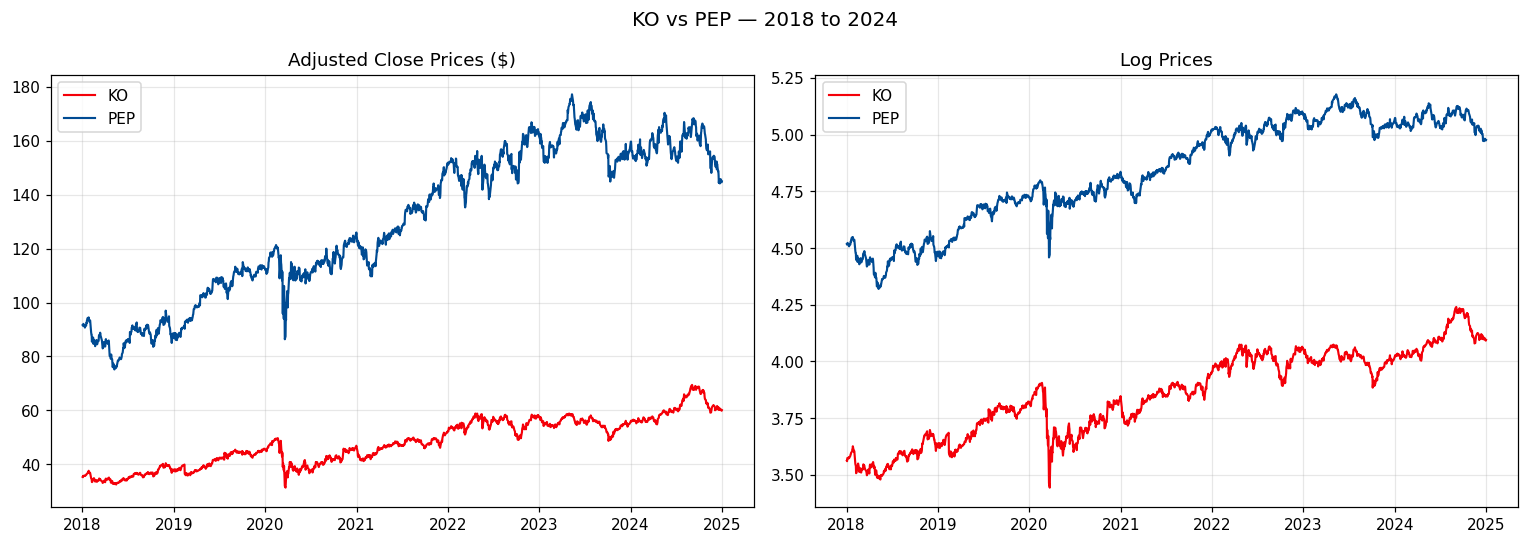

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, transform) in zip(
    axes,
    [("Adjusted Close Prices ($)", lambda x: x),
     ("Log Prices", np.log)],
):
    ax.plot(prices.index, transform(prices["KO"]), color=KO_COLOR, label="KO", linewidth=1.4)
    ax.plot(prices.index, transform(prices["PEP"]), color=PEP_COLOR, label="PEP", linewidth=1.4)
    ax.set_title(title)
    ax.legend()
    fmt_dates(ax)

fig.suptitle("KO vs PEP — 2018 to 2024", fontsize=13)
plt.tight_layout()
plt.show()

## Plot 2 — Daily Returns

Return series (top) and histogram (bottom) for each ticker.

Things to note:
- **Kurtosis** measures fat tails. KO's kurtosis ~9 and PEP's ~20 mean extreme days
  happen far more often than a normal distribution would predict
- **PEP kurtosis ~20** is very high — a handful of extreme outlier days are pulling it up
  (likely the massive EPS misses we saw in the earnings data)
- **Negative skew** on both: the left tail (bad days) is fatter than the right

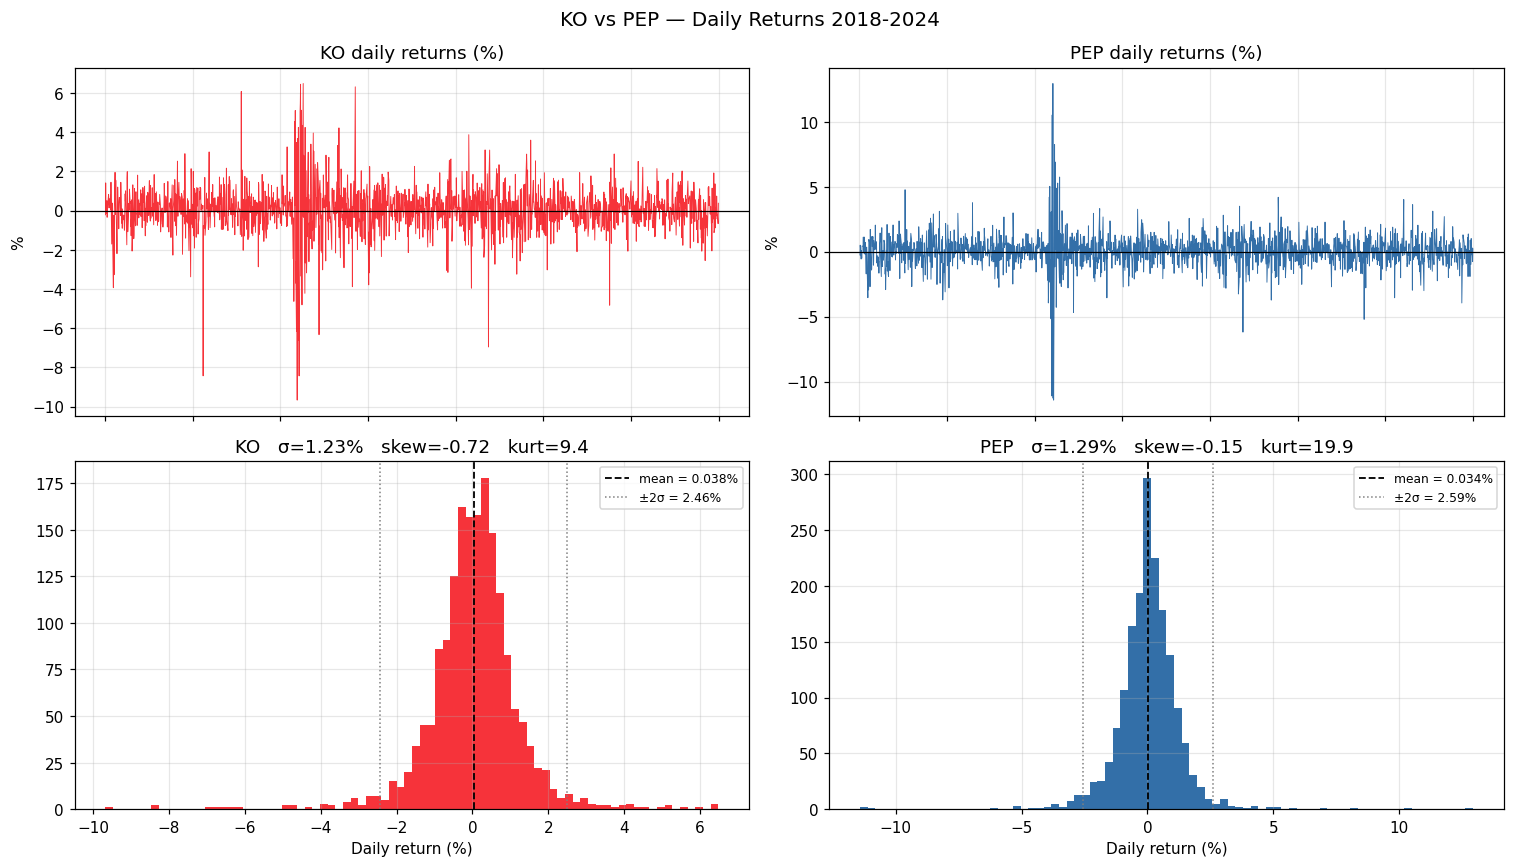

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (ticker, color) in zip(axes[0], [("KO", KO_COLOR), ("PEP", PEP_COLOR)]):
    ax.plot(returns.index, returns[ticker] * 100, color=color, linewidth=0.6, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{ticker} daily returns (%)")
    ax.set_ylabel("%")
    fmt_dates(ax)

for ax, (ticker, color) in zip(axes[1], [("KO", KO_COLOR), ("PEP", PEP_COLOR)]):
    r = returns[ticker] * 100
    ax.hist(r, bins=80, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(r.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"mean = {r.mean():.3f}%")
    ax.axvline(r.mean() + 2*r.std(), color="gray", linestyle=":",
               linewidth=1, label=f"\u00b12\u03c3 = {2*r.std():.2f}%")
    ax.axvline(r.mean() - 2*r.std(), color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Daily return (%)")
    ax.set_title(f"{ticker}   \u03c3={r.std():.2f}%   skew={r.skew():.2f}   kurt={r.kurtosis():.1f}")
    ax.legend(fontsize=8)

fig.suptitle("KO vs PEP — Daily Returns 2018-2024", fontsize=13)
plt.tight_layout()
plt.show()

## Plot 3 — Rolling 63-Day Correlation

A single full-sample correlation number hides regime changes. The rolling version
tells us *when* the pair was tightly coupled and when it drifted.

**63 trading days ≈ 1 quarter** — a natural window for two companies that report
earnings quarterly.

**Red dashed line at 0.30**: pairs trades become unreliable when rolling correlation
drops below this. Any sustained period below it is worth investigating.

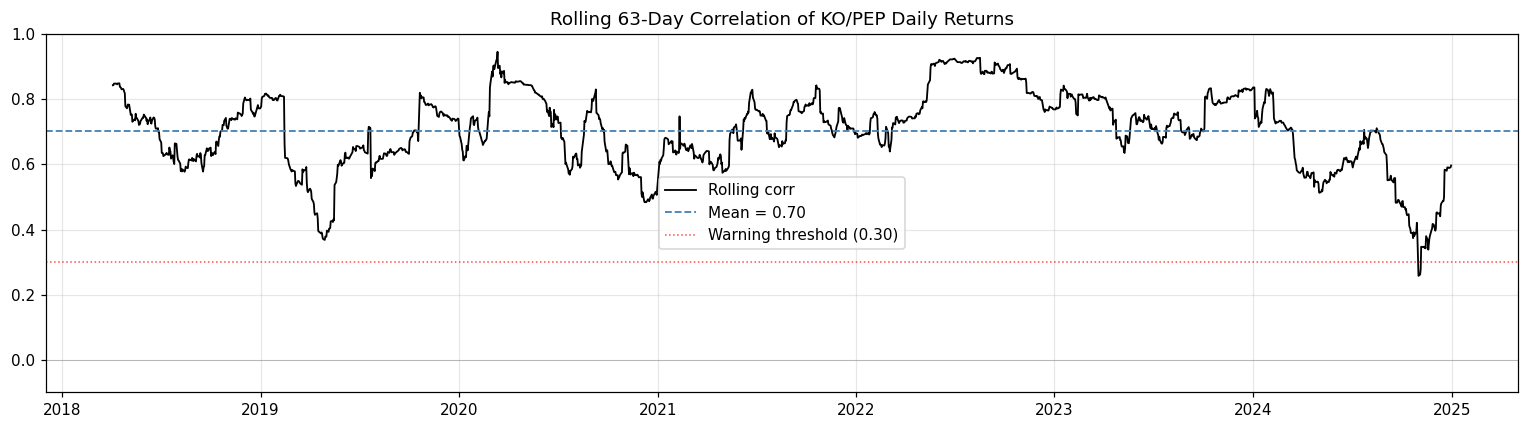

Min:  0.258
Mean: 0.703
Max:  0.946

Days below 0.30 threshold: 3


In [5]:
rolling_corr = returns["KO"].rolling(63).corr(returns["PEP"])
mean_corr = rolling_corr.mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_corr.index, rolling_corr, color="black", linewidth=1.2, label="Rolling corr")
ax.axhline(mean_corr, color="steelblue", linestyle="--", linewidth=1.2,
           label=f"Mean = {mean_corr:.2f}")
ax.axhline(0.30, color="red", linestyle=":", linewidth=1, alpha=0.7,
           label="Warning threshold (0.30)")
ax.axhline(0, color="gray", linewidth=0.6, alpha=0.5)
ax.set_title("Rolling 63-Day Correlation of KO/PEP Daily Returns")
ax.set_ylim(-0.1, 1.0)
ax.legend()
fmt_dates(ax)
plt.tight_layout()
plt.show()

print(f"Min:  {rolling_corr.min():.3f}")
print(f"Mean: {rolling_corr.mean():.3f}")
print(f"Max:  {rolling_corr.max():.3f}")
print(f"\nDays below 0.30 threshold: {(rolling_corr < 0.30).sum()}")

## Plot 4 — Raw Price Ratio

This is `KO / PEP` with no hedge ratio fitted yet — just the raw price ratio.
It's a rough preview of what the spread will look like.

If this ratio is relatively mean-reverting visually, that's encouraging. After
Step 3 we'll fit β via OLS and use the properly scaled spread instead.

The mean ratio ~0.375 tells us KO trades at about 37.5 cents for every dollar
of PEP — that'll inform the ballpark for β when we run the regression.

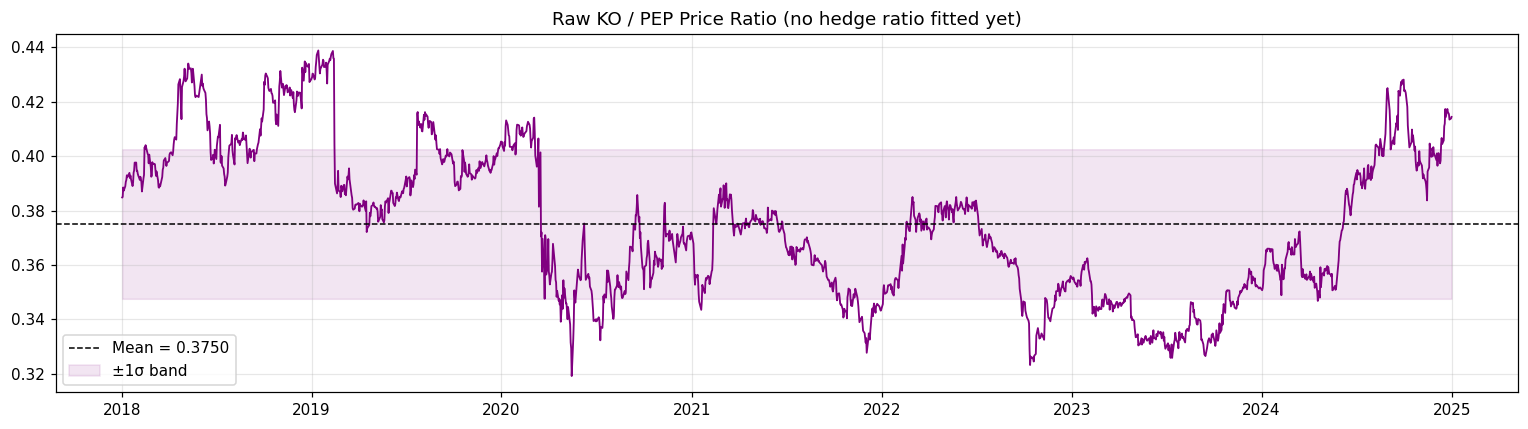

Mean ratio : 0.3750
Std        : 0.0275
CV (std/mean): 0.073  (lower = more stable)


In [6]:
ratio = prices["KO"] / prices["PEP"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ratio.index, ratio, color="purple", linewidth=1.2)
ax.axhline(ratio.mean(), color="black", linestyle="--", linewidth=1,
           label=f"Mean = {ratio.mean():.4f}")
ax.fill_between(ratio.index,
                ratio.mean() - ratio.std(),
                ratio.mean() + ratio.std(),
                color="purple", alpha=0.1, label="\u00b11\u03c3 band")
ax.set_title("Raw KO / PEP Price Ratio (no hedge ratio fitted yet)")
ax.legend()
fmt_dates(ax)
plt.tight_layout()
plt.show()

print(f"Mean ratio : {ratio.mean():.4f}")
print(f"Std        : {ratio.std():.4f}")
print(f"CV (std/mean): {ratio.std()/ratio.mean():.3f}  (lower = more stable)")

## Summary

| Observation | Implication |
|---|---|
| Log prices move roughly in parallel | Cointegration is plausible |
| Return correlation 0.70+ on average | Strong co-movement |
| Rolling corr minimum ~0.26 | One stretch of weaker coupling — worth noting |
| PEP kurtosis ~20 | A few extreme PEP-specific days exist; look for them on plots |
| Price ratio CV ≈ 0.073 | Ratio is reasonably stable — spread should be tradeable |

**Next: Step 3 — OLS hedge ratio estimation.** We'll run `KO ~ PEP` regression
to find the β that minimises spread variance, then construct the proper spread series.